In [4]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD THE DATA (This defines 'df')
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['price'] = housing.target

# 2. INITIALIZE THE SCALER (This defines 'scalar')
scalar = StandardScaler()

# 3. SELECT FEATURES FOR CLUSTERING
features_to_clusters = ['Latitude', 'Longitude', 'MedInc']
X_cluster = df[features_to_clusters]

# 4. SCALE THE DATA
X_scaled = scalar.fit_transform(X_cluster)

# 5. RUN K-MEANS
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster_ID'] = kmeans.fit_predict(X_scaled)

# 6. SHOW THE RESULTS
cluster_stats = df.groupby('cluster_ID')[['price', 'MedInc', 'HouseAge']].mean()
print(cluster_stats)

               price     MedInc   HouseAge
cluster_ID                                
0           1.648604   2.701510  29.860669
1           2.803007   5.397651  27.259382
2           2.640310   5.179153  26.391266
3           4.624667  10.289102  27.534653
4           1.447890   2.734424  29.818478


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

features_with_clusters = housing.feature_names + ['cluster_ID']

X_enhanced = df[features_with_clusters]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X_enhanced, y, test_size=0.2, random_state=42)

rf_enhanced = RandomForestRegressor(n_estimators=100, random_state=42)
rf_enhanced.fit(X_train, y_train)

new_score = rf_enhanced.score(X_test, y_test)
print(f"Original R-squared: 0.7757")
print(f"Enhanced R-squared: {new_score:.4f}")

Original R-squared: 0.7757
Enhanced R-squared: 0.8041


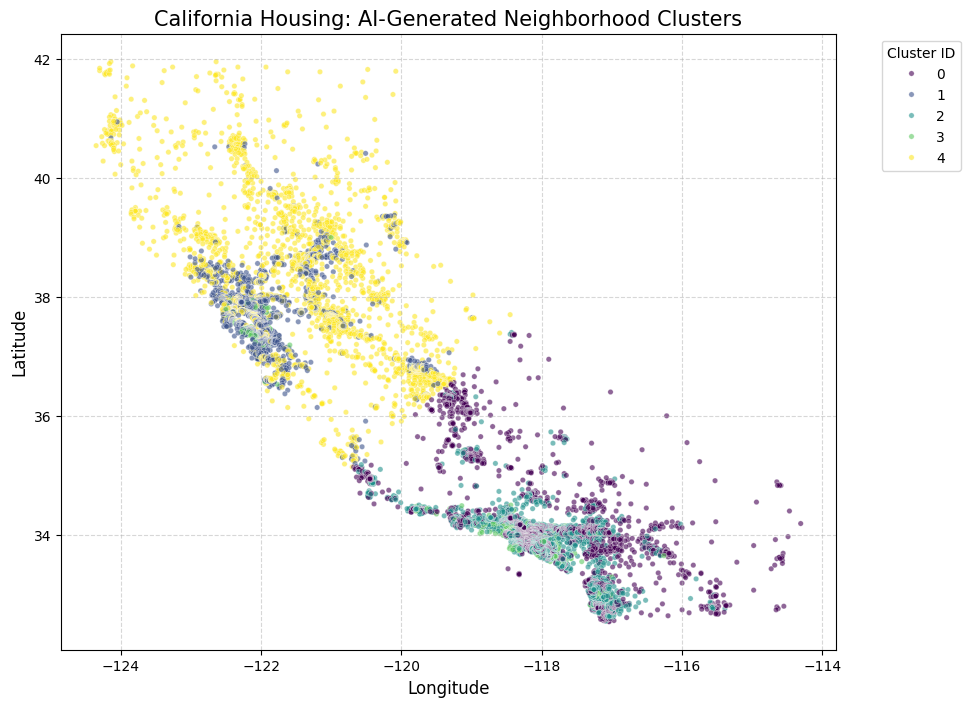

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.scatterplot(data=df, x='Longitude', y='Latitude', hue='cluster_ID',
                palette='viridis', alpha=0.6, s=15)

plt.title('California Housing: AI-Generated Neighborhood Clusters', fontsize=15)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.legend(title='Cluster ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

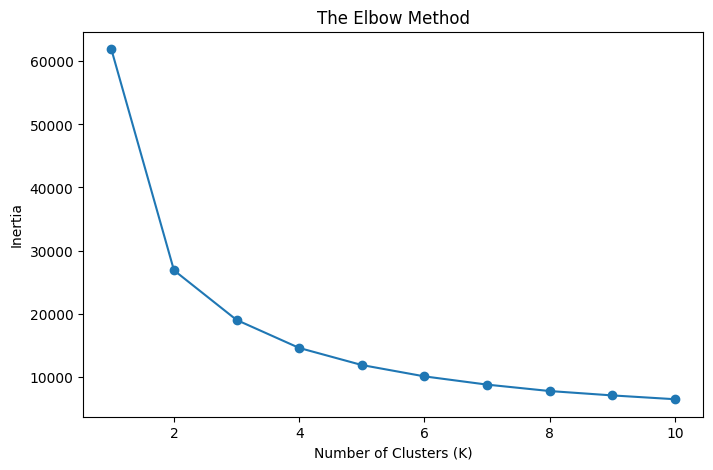

In [8]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Plot the "Elbow"
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()